In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Open the spreadsheet

In [2]:
# 1. Define the file path and sheet name
file_path = 'graph_ingredients.xlsx'
sheet = 'Edge List_Expanded'

# 2. Load data into a DataFrame

In [3]:
# 2. Read the Excel file into a DataFrame
df = pd.read_excel(file_path, sheet_name=sheet)

# 3. View the first few rows to confirm it worked
print(df.head())

df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce').fillna(0)

    Source                 Target  Weight  \
0     Root                Younger     0.4   
1     Root               Same age     0.4   
2     Root                  Older     0.2   
3  Younger  Younger (child's gen)     0.5   
4  Younger     Younger (same gen)     0.5   

                                             Note  \
0  Branch probability = 0.4 (Estimated frequency)   
1  Branch probability = 0.4 (Estimated frequency)   
2  Branch probability = 0.2 (Estimated frequency)   
3         Branch probability = 0.5 (Evenly split)   
4         Branch probability = 0.5 (Evenly split)   

                          Cumulative Logic  
0                   1.0 (Root) * 0.4 = 0.4  
1                   1.0 (Root) * 0.4 = 0.4  
2                   1.0 (Root) * 0.2 = 0.2  
3  0.4 (Incoming from Younger) * 0.5 = 0.2  
4  0.4 (Incoming from Younger) * 0.5 = 0.2  


# 3. Create the Graph

In [4]:
# 3. Create the Graph
G = nx.from_pandas_edgelist(df, source='Source', target='Target', edge_attr='Weight')

# 4. Visualize

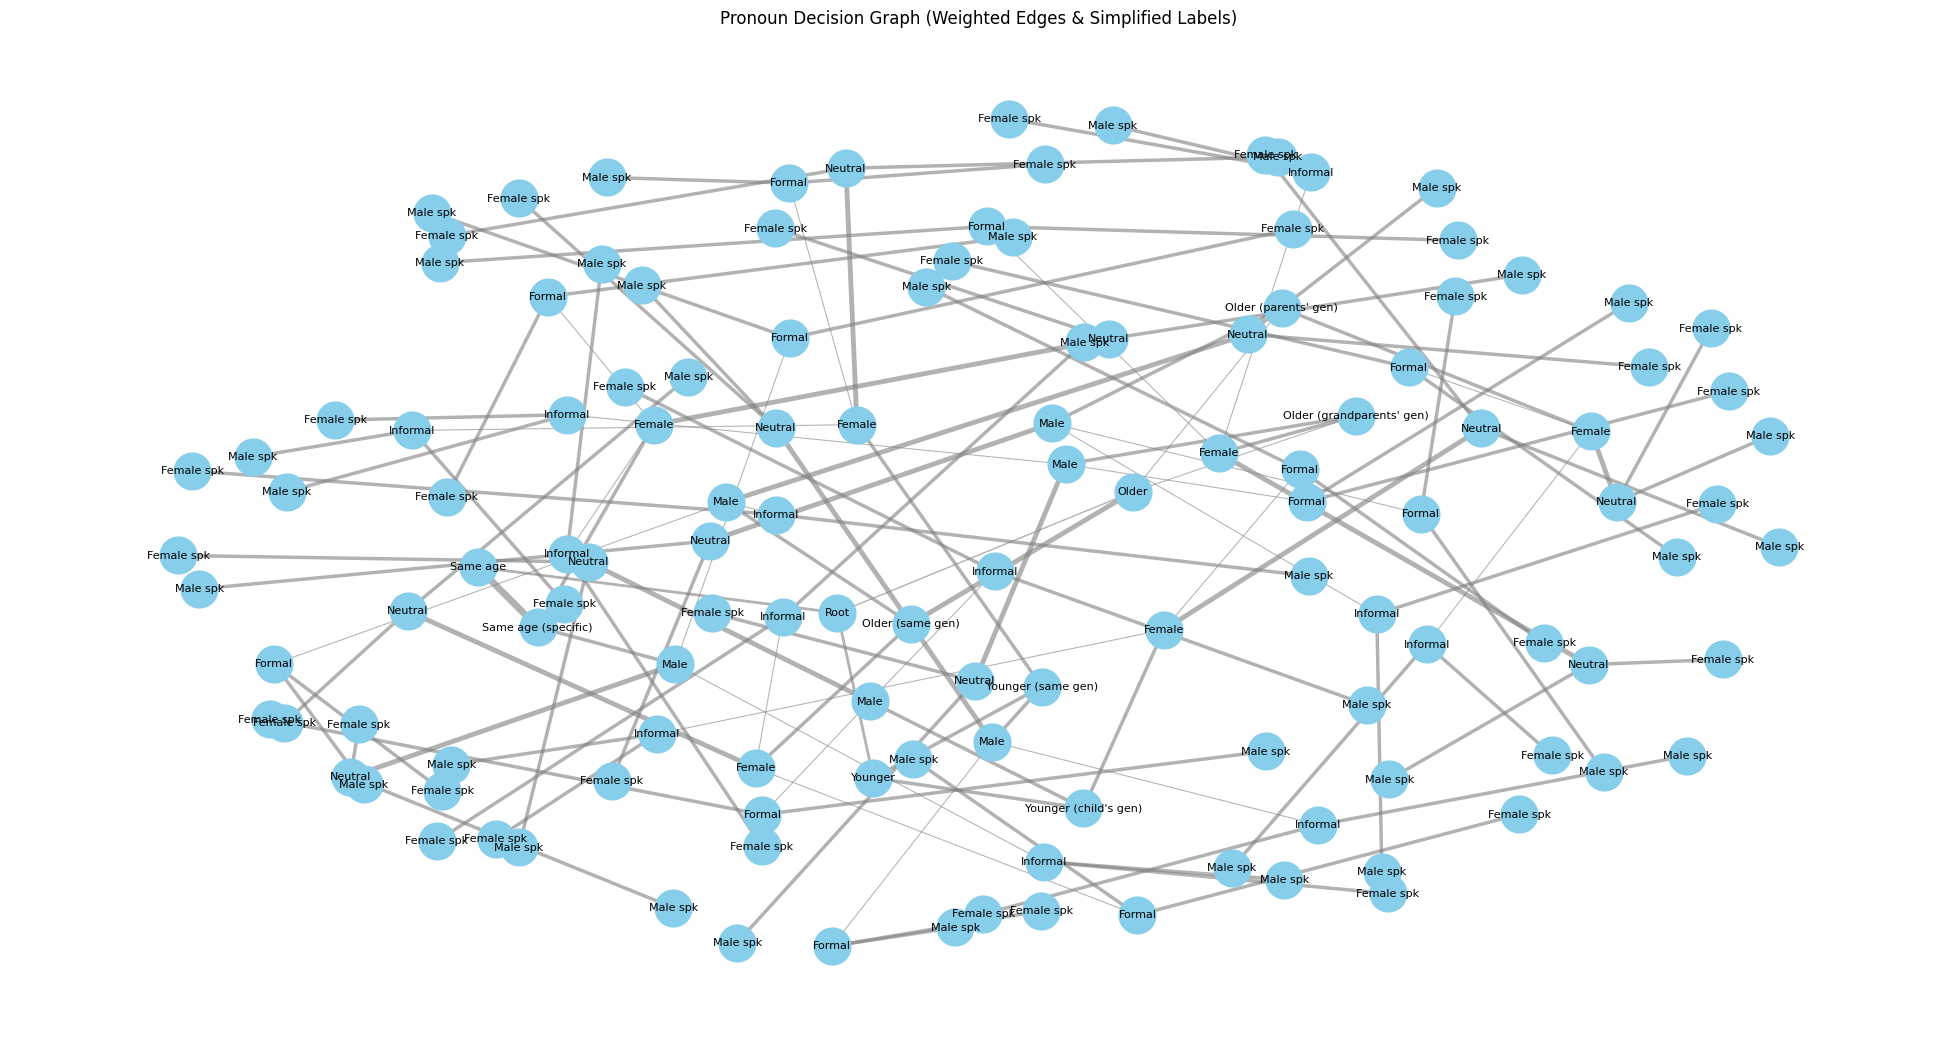

In [5]:
plt.figure(figsize=(25, 13)) # Increased height slightly for better spacing
pos = nx.spring_layout(G, k=0.5) # Layout for nodes

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')

# Draw edges with thickness based on Weight
weights = [G[u][v]['Weight'] * 5 for u, v in G.edges()] # Scaling weight for visibility
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)

# --- MODIFICATION: Create simplified labels ---
# This splits the string by " - " and takes the very last element
# Example: "Younger - Male - Neutral" becomes just "Neutral"
short_labels = {node: str(node).split(' - ')[-1] for node in G.nodes()}

# Draw labels using the new 'labels' parameter
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_family='sans-serif')

plt.title("Pronoun Decision Graph (Weighted Edges & Simplified Labels)")
plt.axis('off')
plt.show()

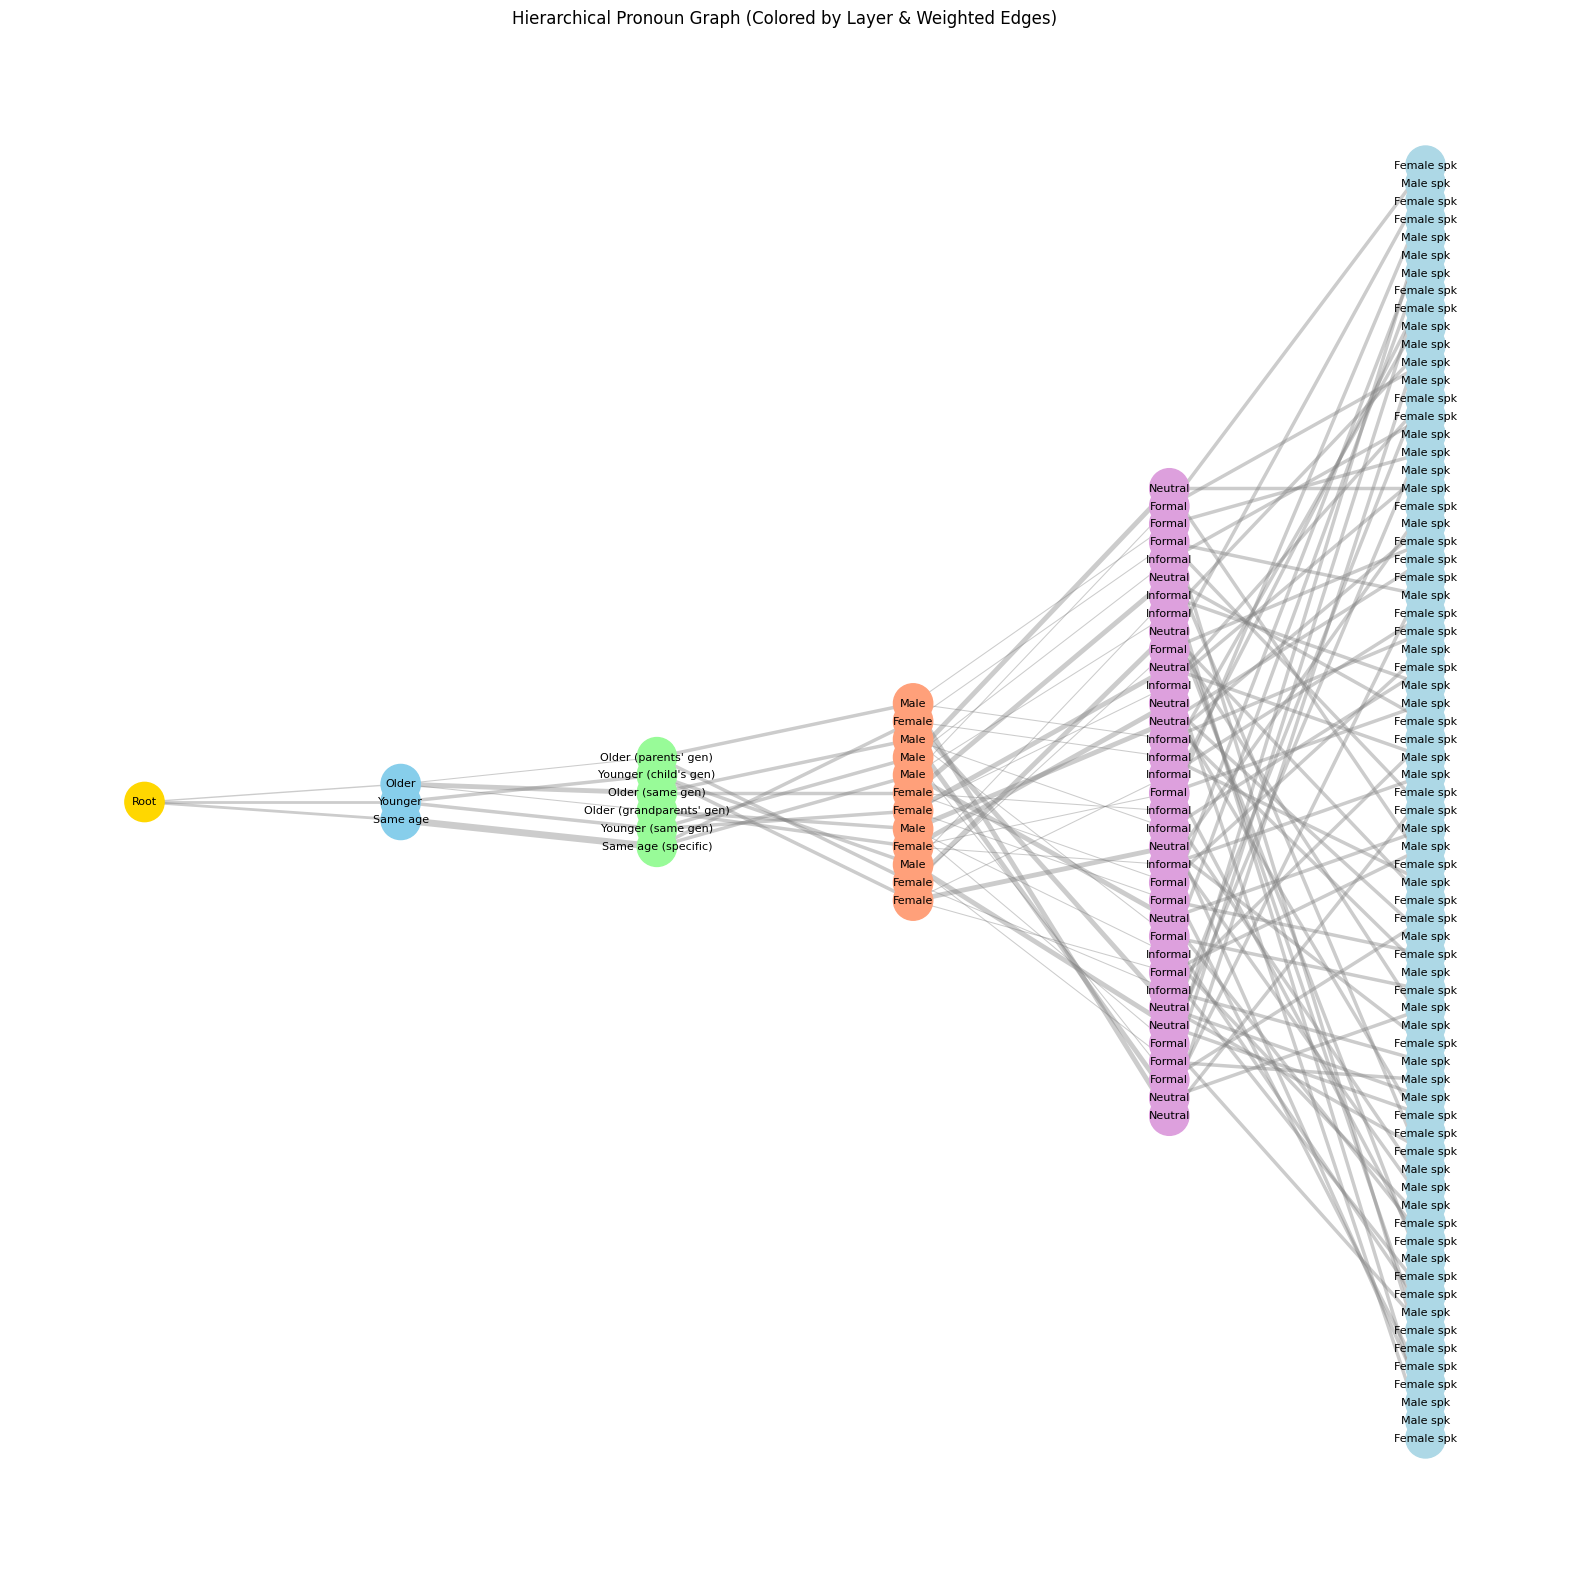

In [6]:
# 1. Calculate depth from Root to determine layers (if not already done)
depths = nx.single_source_shortest_path_length(G, 'Root')
for node, depth in depths.items():
    G.nodes[node]['layer'] = depth

# 2. Define your color palette for each layer
# Layer 0: Root, Layer 1: Age, Layer 2: Gender, Layer 3: Social, Layer 4: Speaker
layer_colors = {
    0: '#FFD700', # Gold
    1: '#87CEEB', # Sky Blue
    2: '#98FB98', # Pale Green
    3: '#FFA07A', # Light Salmon
    4: '#DDA0DD', # Plum
    5: '#ADD8E6'  # Light Blue - Added for layer 5
}

# 3. Create a list of colors for each node in the order they appear in G.nodes()
node_colors = [layer_colors[G.nodes[n]['layer']] for n in G.nodes()]

# 4. Visualize
plt.figure(figsize=(20, 20))
# Use multipartite_layout for the hierarchical look
pos = nx.multipartite_layout(G, subset_key='layer')

# Draw nodes with the new node_colors list
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors)

# Draw edges with thickness based on Weight
weights = [G.get_edge_data(u, v, default={}).get('Weight', 0) * 5 for u, v in G.edges()] # Added .get('Weight', 0) to handle missing 'Weight' attribute
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.4)

# Create simplified labels
short_labels = {node: str(node).split(' - ')[-1] for node in G.nodes()}

# Draw labels
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_family='sans-serif')

plt.title("Hierarchical Pronoun Graph (Colored by Layer & Weighted Edges)")
plt.axis('off')
plt.show()

## ⭐ **WE CAN MODIFY THE WEIGHTS or YOU GUYS CAN ADD YOUR FEEDBACKS/IDEAS HERE**

* Age: Most of people in the target group know how to address pronouns to the older, but face difficulties with youngers and same age.
  * Root - Younger: 0.4
  * Root - Same age: 0.4
  * Root - Older: 0.2
* Age (specific):
  * Younger group:
    * younger - Younger (child's gen): 0.5
    * Younger - Younger (same gen): 0.5
  * Same age group
    * Same age- Same age: 1
  * Older group: Target group mostly talks vietnamese to people who are around parents' or grandparents' gen
    * Older - Older (same gen): 0.7
    * Older - Older (parents' gen): 0.15
    * Older - Older (grandparents' gen): 0.15
* Gender:
  * ~ - Male: 0.5
  * ~ - Female: 0.5
* Social: The game is now designed for social situations. In my opinion, the case neutral can be the most frequent that learners can face, when they talk to others in real life. But we can modify the weight for this layer. At the moment, I set it as:
  * ~ - Informal: 0.15
  * ~ - Neutral: 0.7
  * ~ - Formal: 0.15
* Speaker gender:
  * ~ - Male: 0.5
  * ~ - Female: 0.5

# 5. Weights → Edges for similarity
Similarity here indicates more frequent scenerios

In [7]:
import itertools

# 1. Identify nodes (layer 5)
"""Extracts Nodes: It finds all the end scenarios (nodes at layer 5)."""

leaf_nodes = [n for n, attr in G.nodes(data=True) if attr.get('layer') == 5]


# 2. Extract features for each node by tracing the shortest path from Root
"""Extracts Features:
    It traces the path back to the root for each node to figure out its specific attributes
    (Age, Age specific, Gender, Social, Speaker Gender)."""

leaf_features = {}
for leaf in leaf_nodes:
    path = nx.shortest_path(G, source='Root', target=leaf)
    # The path contains nodes at each layer:
    # [Root, Age, Age(specific), Gender, Social, Speaker Gender]
    age = path[1]
    age_spec = path[2]
    # Extract just the specific attribute name from the long node label
    gender = path[3].split(' - ')[-1]
    social = path[4].split(' - ')[-1]
    spk_gender = path[5].split(' - ')[-1]

    leaf_features[leaf] = [age, age_spec, gender, social, spk_gender]


# 3. Define the weights for each feature value based on our requirements
weight_dict = {
    'Younger': 0.4, 'Same age': 0.4, 'Older': 0.2,
    "Younger (child's gen)": 0.5, 'Younger (same gen)': 0.5,
    'Same age (specific)': 1.0,  # Updated to match the restored label
    'Older (same gen)': 0.7, "Older (parents' gen)": 0.15, "Older (grandparents' gen)": 0.15,
    'Male': 0.5, 'Female': 0.5,
    'Informal': 0.15, 'Neutral': 0.7, 'Formal': 0.15,
    'Male spk': 0.5, 'Female spk': 0.5
}


# 4. Calculate similarity scores between all pairs of nodes
"""Calculates Similarity:
    It compares every pair of nodes.
    If they share an attribute, it adds the weight of that attribute to their similarity score."""

similarity_edges = []
for u, v in itertools.combinations(leaf_nodes, 2):
    feat_u = leaf_features[u]
    feat_v = leaf_features[v]

    sim_score = 0
    for f1, f2 in zip(feat_u, feat_v):
        if f1 == f2:
            # Add the weight if they share the same feature. Default to 0.1 if not found just in case.
            sim_score += weight_dict.get(f1, 0.1)

    # Only add an edge if the similarity is reasonably high
    # The max possible score is 0.4 + 1.0 + 0.5 + 0.7 + 0.5 = 3.1 (Eg: Same age - Same age - Female - Neutral - Female Spk)
    if sim_score >= 1.8:
      # set it to 1.8 to avoid a completely cluttered graph, but we can adjust this
        similarity_edges.append((u, v, sim_score))


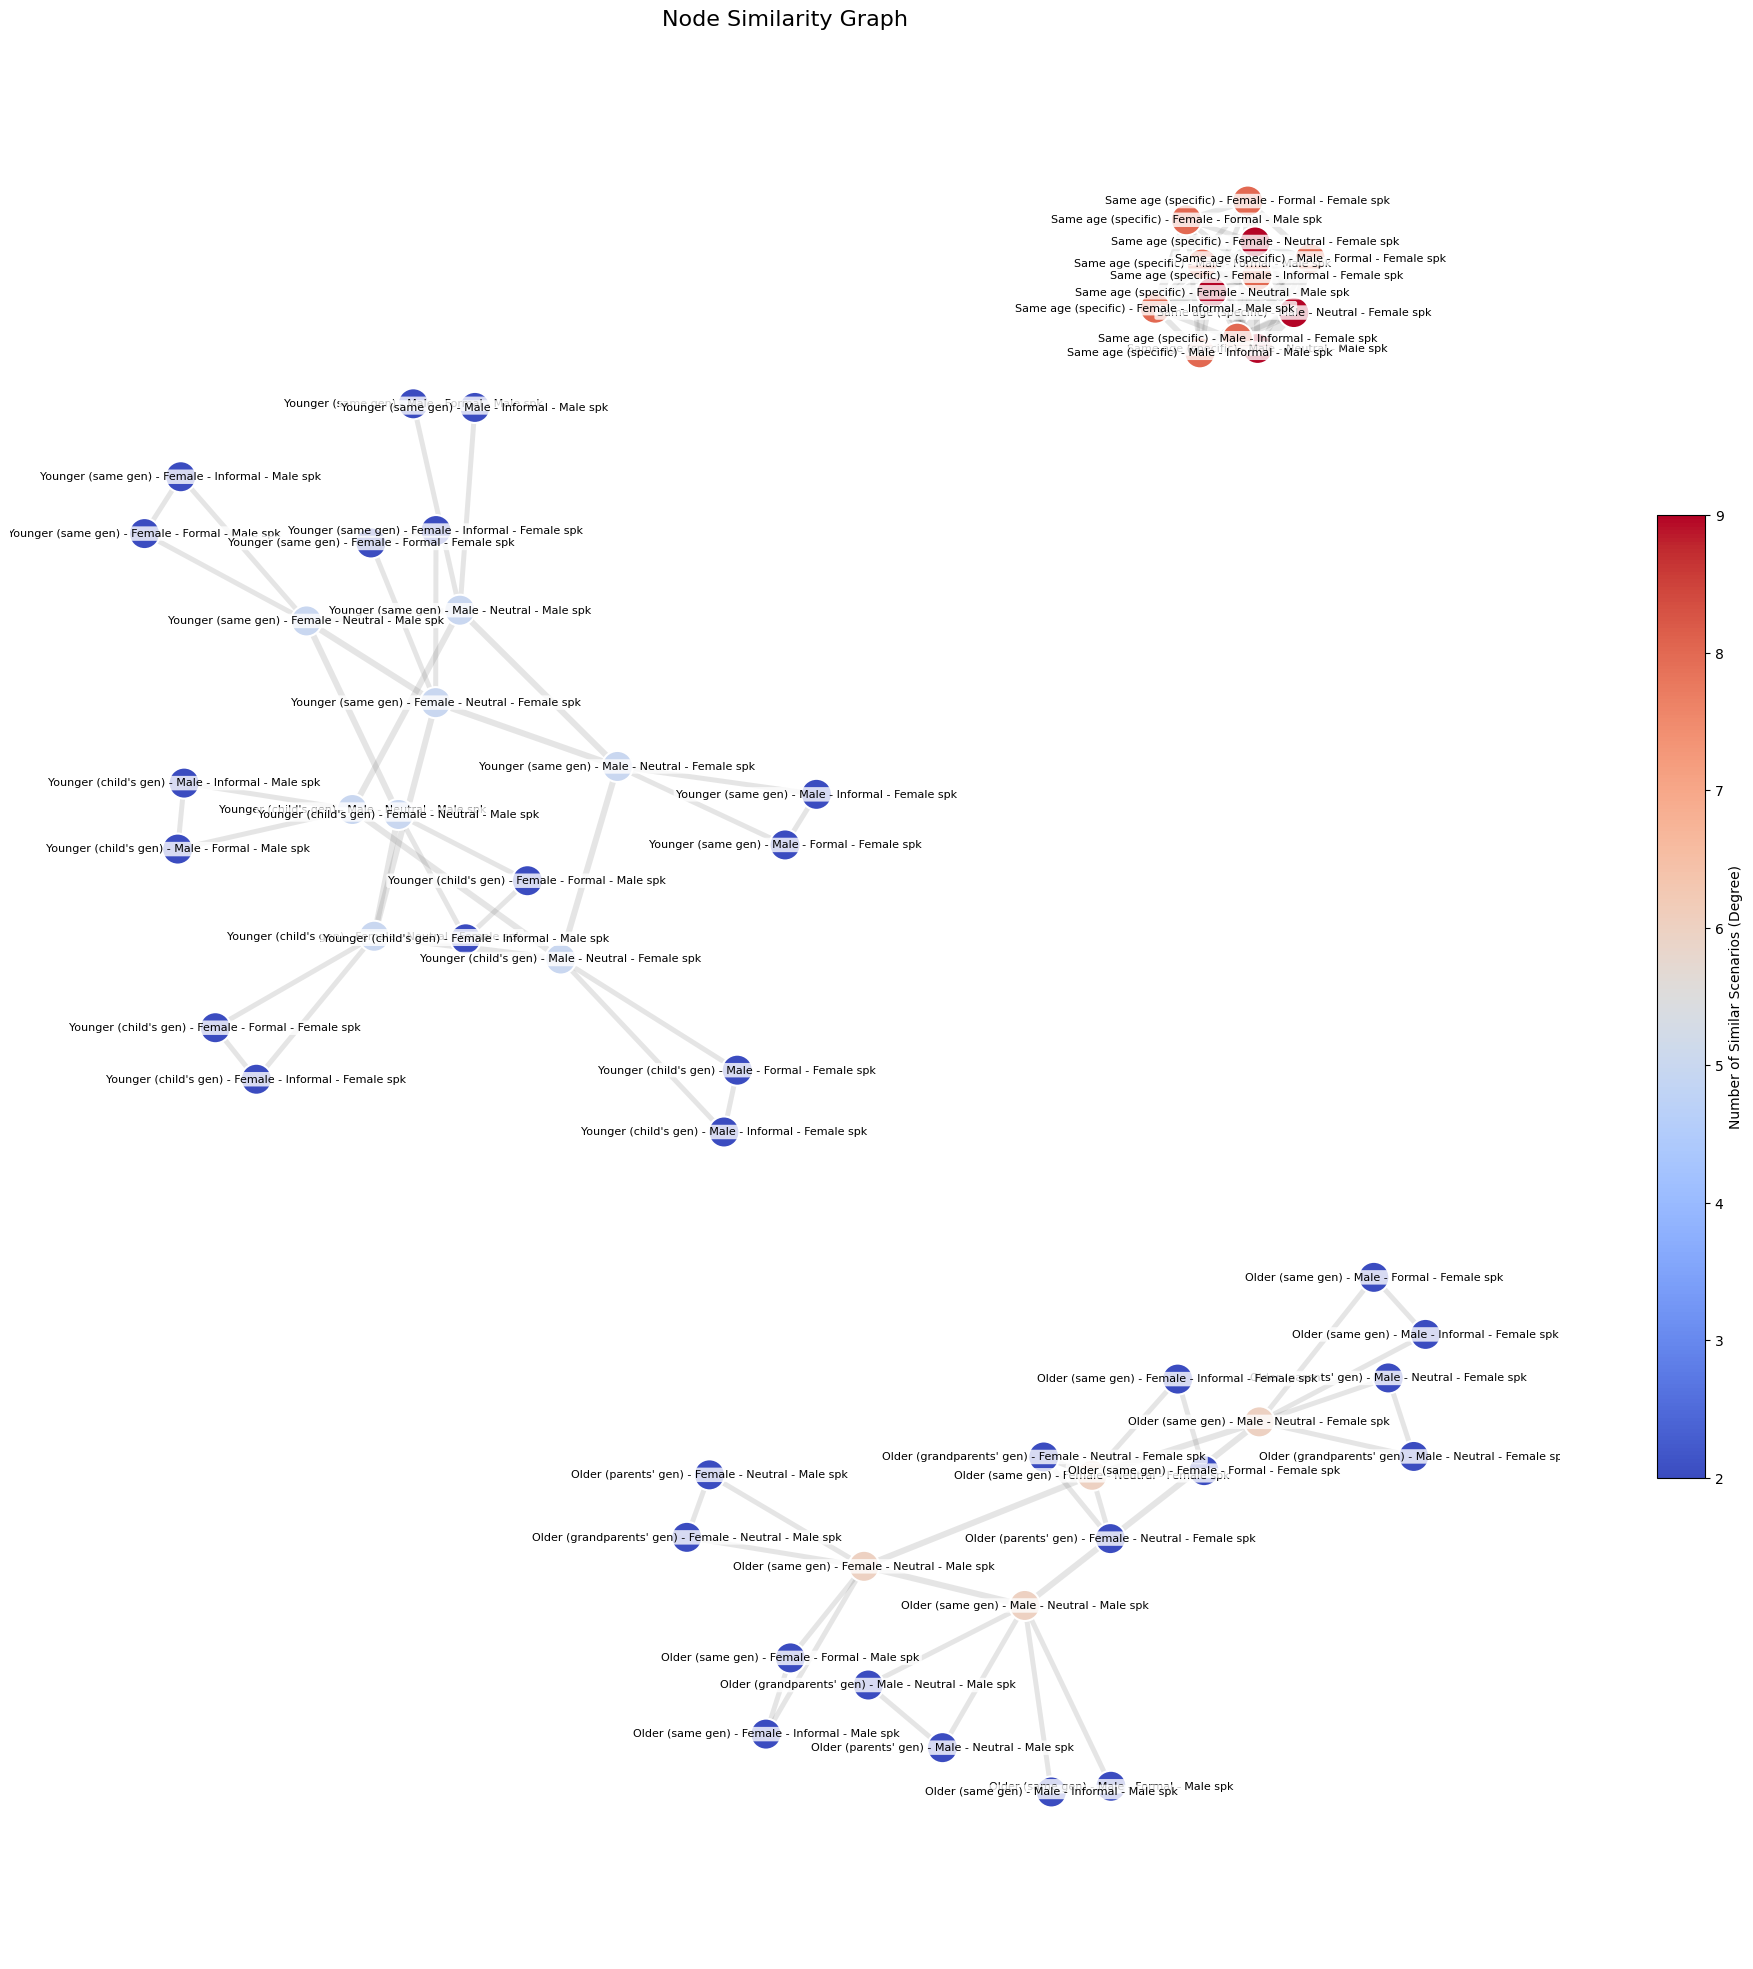

In [8]:
# 5. Create and Visualize the Similarity Graph
"""Visualizes:
    It plots a new graph where edges only exist if the similarity score is above a certain threshold
    (At the moment, set it to 1.8 to avoid a completely cluttered graph, but we can adjust this).
    Thicker edges mean higher similarity."""

S = nx.Graph()
for u, v, w in similarity_edges:
    S.add_edge(u, v, weight=w)

# Adjusted 'k' for better spacing between clusters, and increased iterations for stability
pos_s = nx.spring_layout(S, k=0.3, iterations=50, seed=42)

# Calculate node degree to use for coloring (more connected = hotter color)
degrees = dict(S.degree())
node_colors = [degrees[n] for n in S.nodes()]

# Define edge_weights based on the similarity scores
edge_weights = [S[u][v]['weight'] ** 2 for u, v in S.edges()]

# 5 = Shows the full path (e.g., "Younger (child's gen) - Male - Informal - Female spk")
parts_to_show = 5

# Create the custom labels based on your choice above
custom_labels = {n: " - ".join(str(n).split(' - ')[-parts_to_show:]) for n in S.nodes()}

# --- Drawing the Graph ---
plt.figure(figsize=(25, 25))

# Re-draw Nodes
nodes = nx.draw_networkx_nodes(S, pos_s, node_size=500, node_color=node_colors,
                               cmap=plt.cm.coolwarm, edgecolors='white', linewidths=1.5)

# Re-draw Edges
nx.draw_networkx_edges(S, pos_s, width=edge_weights, alpha=0.15, edge_color='#555555')

# Draw the Custom Labels
nx.draw_networkx_labels(S, pos_s, labels=custom_labels, font_size=8, font_family='sans-serif',
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title(f"Node Similarity Graph", fontsize=16)
plt.axis('off')
plt.colorbar(nodes, label="Number of Similar Scenarios (Degree)", shrink=0.5, aspect=20)
plt.show()

# Based on everything above, save graph + export graph

In [11]:
import pandas as pd
import networkx as nx
import uuid
import json
from networkx.readwrite import json_graph

G_schema = nx.DiGraph() 
db_df = pd.read_excel("db_pronouns_social-adressing_v1.xlsx", sheet_name="input_nodes")
db_df = db_df[~db_df['adressing relation'].str.contains("child", na=False)] 

def map_game_nodes(row):
    relation = str(row['adressing relation']).lower()
    note = str(row['any note?']).lower()
    
    # Layer 1: Specific Generations
    if "younger" in relation: age = "Younger"
    elif "middle-age" in relation or "parents" in relation: age = "Middle-aged (parents' gen)"
    elif "senior" in relation or "grandparent" in relation: age = "Senior (grandparents' gen)"
    elif "older" in relation: age = "Older (same gen)"
    else: age = "Same Age"
        
    # Layer 2: Addressee Gender
    addr_options = ["Male", "Female"]
    if "you as male" in note or "bhai (male)" in note or "uncle" in relation or "uncle" in note: 
        addr_options = ["Male"]
    elif "you as female" in note or "baji/apa (female)" in note or "aunt" in relation or "aunty" in note or "khala" in note: 
        addr_options = ["Female"]

    # Layer 3: Social Context
    social_options = ["Neutral"]
    # 🌟 FIXED: Check for casual/informal FIRST so they don't overlap!
    if "casual" in note or "informal" in note: 
        social_options = ["Informal"]
    elif "formal" in note or "polite" in note or "respect" in note: 
        social_options = ["Formal"]
        
    # Layer 4: Speaker Gender
    spk_options = ["Male spk", "Female spk"]
    if "i/me as male" in note: spk_options = ["Male spk"]
    elif "i/me as female" in note: spk_options = ["Female spk"]

    paths = []
    for addr in addr_options:
        for social in social_options:
            for spk in spk_options:
                paths.append(f"{age} - {addr} - {social} - {spk}")
    return paths

for index, row in db_df.iterrows():
    target_paths = map_game_nodes(row)
    for path in target_paths:
        G_schema.add_node(path, type="schema_path", layer=4)

G_plugged = G_schema.copy()
for index, row in db_df.iterrows():
    target_paths = map_game_nodes(row)
    instance_id = f"Instance_{uuid.uuid4().hex[:6]}"
    term_i = str(row['terms (i/me)']).strip() if pd.notna(row['terms (i/me)']) else ""
    term_you = str(row['terms (you)']).strip() if pd.notna(row['terms (you)']) else ""
    lang = row['language']
    
    if term_i == "" and term_you == "": continue
        
    G_plugged.add_node(instance_id, type="instance", language=lang, term_i=term_i, term_you=term_you)
    for path in target_paths:
        G_plugged.add_edge(path, instance_id, type="HAS_PRONOUN")

plugged_data = json_graph.node_link_data(G_plugged)
with open("graph_export/graph_plugged_data.json", "w", encoding="utf-8") as f:
    json.dump(plugged_data, f, ensure_ascii=False, indent=4)
print("✅ Saved 'graph_plugged_data.json'")

✅ Saved 'graph_plugged_data.json'


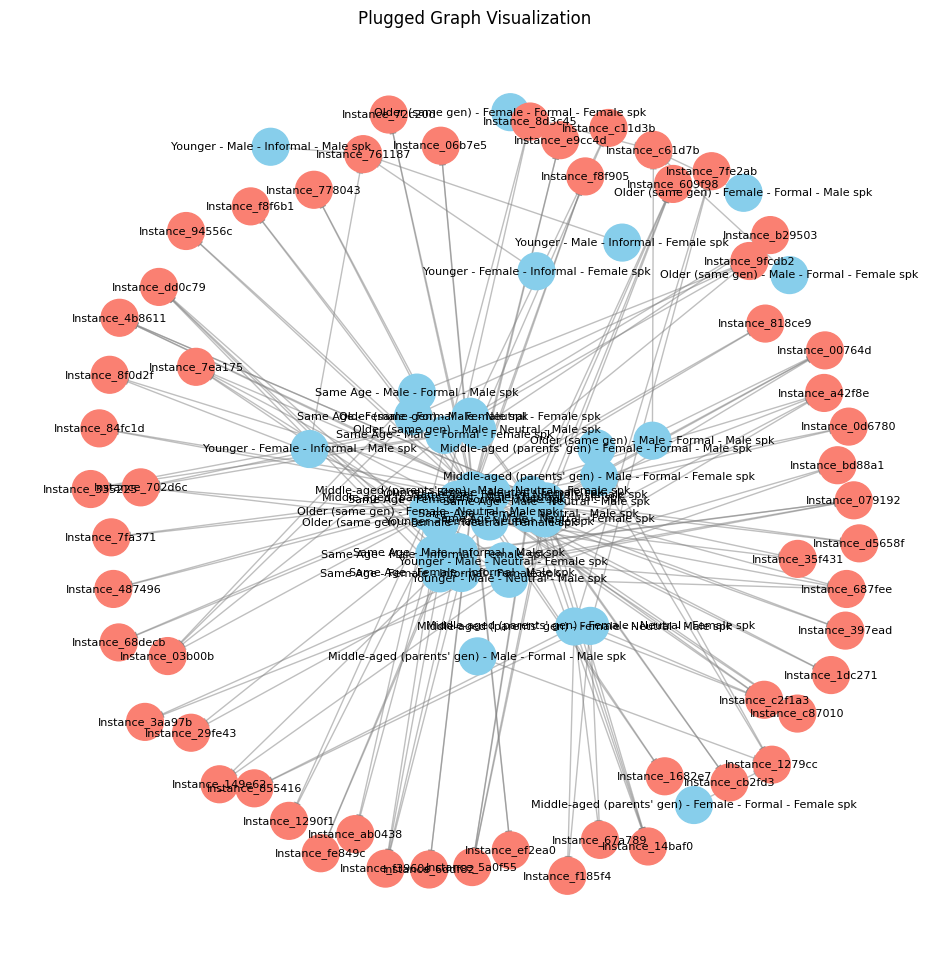

In [12]:
# Visualize the Plugged Graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_plugged, k=0.5, iterations=50, seed=42)
node_colors = ['skyblue' if G_plugged.nodes[n]['type'] == 'schema_path' else 'salmon' for n in G_plugged.nodes()]
nx.draw_networkx_nodes(G_plugged, pos, node_size=700, node_color=node_colors)
nx.draw_networkx_edges(G_plugged, pos, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G_plugged, pos, font_size=8, font_family='sans-serif')
plt.title("Plugged Graph Visualization")
plt.axis('off')
plt.show()

In [13]:
import pandas as pd
import itertools

# Create a list to hold our data
nodes_data = []
edges_data = []
confusion_data = []

# ==========================================
# 1. EXPORT NODES (Paths and Pronoun Instances)
# ==========================================
for node, attr in G_plugged.nodes(data=True):
    nodes_data.append({
        'Node ID': node,
        'Node Type': attr.get('type', ''),
        'Language': attr.get('language', 'N/A'),
        'Term (I/Me)': attr.get('term_i', 'N/A'),
        'Term (You)': attr.get('term_you', 'N/A')
    })

nodes_df = pd.DataFrame(nodes_data)
# We use 'utf-8-sig' so Excel reads the Asian/Arabic characters perfectly!
nodes_df.to_csv('graph_export/artifacts/nodes.csv', index=False, encoding='utf-8-sig')
print(f"✅ Saved 'nodes.csv' ({len(nodes_df)} rows)")


# ==========================================
# 2. EXPORT EDGES (The Connections)
# ==========================================
for source, target, attr in G_plugged.edges(data=True):
    edges_data.append({
        'Source (Path)': source,
        'Target (Instance)': target,
        'Relationship': attr.get('type', 'HAS_PRONOUN')
    })

edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('graph_export/artifacts/edges.csv', index=False, encoding='utf-8-sig')
print(f"✅ Saved 'edges.csv' ({len(edges_df)} edges)")


# ==========================================
# 3. EXPORT CONFUSION MATRIX (Similarity)
# ==========================================
# We will compare instances within the SAME language to find highly similar pairs
instance_nodes = [n for n, attr in G_plugged.nodes(data=True) if attr.get('type') == 'instance']

# Group instances by language
langs_dict = {}
for n in instance_nodes:
    lang = G_plugged.nodes[n]['language']
    if lang not in langs_dict:
        langs_dict[lang] = []
    langs_dict[lang].append(n)

# Find confusing pairs
for lang, instances in langs_dict.items():
    # Compare every unique pair of pronouns in this language
    for inst1, inst2 in itertools.combinations(instances, 2):
        data1 = G_plugged.nodes[inst1]
        data2 = G_plugged.nodes[inst2]
        
        # Don't compare identical text strings
        if data1.get('term_i') == data2.get('term_i') and data1.get('term_you') == data2.get('term_you'):
            continue
            
        # Get the paths connected to these pronouns
        paths1 = list(G_plugged.predecessors(inst1))
        paths2 = list(G_plugged.predecessors(inst2))
        
        max_matches = -1
        best_p1, best_p2 = "", ""
        diff_feature = ""
        
        # Check all path combinations between the two pronouns
        for p1 in paths1:
            for p2 in paths2:
                parts1 = p1.split(' - ')
                parts2 = p2.split(' - ')
                
                # Count how many variables match (Age, Addressee, Social, Speaker)
                matches = sum(1 for f1, f2 in zip(parts1, parts2) if f1 == f2)
                
                if matches > max_matches:
                    max_matches = matches
                    best_p1 = p1
                    best_p2 = p2
                    
                    # If exactly 3 out of 4 match, it's a high-confusion pair!
                    if matches == 3:
                        diff_idx = [i for i, (f1, f2) in enumerate(zip(parts1, parts2)) if f1 != f2][0]
                        feature_names = ["Age Group", "Addressee Gender", "Social Context", "Speaker Gender"]
                        diff_feature = feature_names[diff_idx]
                        
        # If the highest similarity is exactly 3 (meaning only 1 trait is different)
        if max_matches == 3:
            confusion_data.append({
                'Language': lang,
                'Pronoun Pair A (I/You)': f"{data1.get('term_i')} / {data1.get('term_you')}",
                'Pronoun Pair B (I/You)': f"{data2.get('term_i')} / {data2.get('term_you')}",
                'What causes confusion?': f"Changes {diff_feature} ONLY",
                'Context A': best_p1,
                'Context B': best_p2
            })

confusion_df = pd.DataFrame(confusion_data)
# Sort by Language so it's easy to read
confusion_df = confusion_df.sort_values(by=['Language', 'What causes confusion?'])
confusion_df.to_csv('graph_export/artifacts/confusion.csv', index=False, encoding='utf-8-sig')
print(f"✅ Saved 'confusion.csv' ({len(confusion_df)} high-confusion pairs found!)")

✅ Saved 'nodes.csv' (92 rows)
✅ Saved 'edges.csv' (148 edges)
✅ Saved 'confusion.csv' (98 high-confusion pairs found!)
